In [1]:
import pandas as pd
import torch.nn.functional as F
import transformers
import argparse
import matplotlib.pyplot as plt
from DataLoad_simple import RNA_Seq_analysis
from model_cmm import miRNAModel,mRNA_encoder,contrastive_mRNA
import os
import random
import tqdm
import numpy as np
import torch
import torch.nn as nn
from torch.utils import data
from transformers import DebertaTokenizerFast, T5EncoderModel, T5Config
import json
import torch.nn.functional as F
from sklearn.metrics import recall_score,f1_score, precision_score, roc_auc_score,confusion_matrix,auc,roc_curve
import matplotlib.pyplot as plt


In [2]:
with open('data/miran2name.json', 'r') as f:
    miran2name = json.load(f)
def find_repeating_unit(seq):
    n = len(seq)
    for i in range(1, n // 2 + 1):  # Try possible lengths for the repeating unit
        unit = seq[:i]
        if unit * (n // i) == seq[:i * (n // i)]:
            # Check if repeating this unit reconstructs the full or almost full string
            if seq == unit * (n // i) or seq.startswith(unit * (n // i)):
                return unit
    return None 

In [50]:
if __name__ == '__main__':
    # Set CUDA device
    #python trainer.py --data_path "data1" --model_name "model_d2v_mfe0_ss0_specific.pt" --load_model True --cuda_device "3"
    #os.environ['OMP_NUM_THREADS'] = '1'
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'
    #torch.cuda.set_device(int(args.cuda_device))
    data_path = 'cds_large'
    DATA_PATH = f'./data/{data_path}.json'
    TOKENIZER_PATH = "./tokenizer_3mers/"
    TOKENIZER_PATH_1mer = "./tokenizer_3mers/"

    MODEL_PATH = './checkpoint/model_mm_3mer_130klong_4_wo_kl.pt'
    criterion_cross = nn.CrossEntropyLoss()
    BATCH_SIZE = 64
    EPOCHS = 1
    encoder_mi = miRNAModel(num_attention_heads=2, num_hidden_layers=4, pad_token_id=3, hidden_size=128).cuda()
    encoder_m = mRNA_encoder(num_attention_heads=2, num_hidden_layers=4, pad_token_id=3, hidden_size=128).cuda()
    ckpt = torch.load(MODEL_PATH, map_location='cpu')
    model = contrastive_mRNA(encoder_mi,encoder_m)
    model.load_state_dict(ckpt['state_dict'], strict=True)
    #print(ckpt['ema']['encoder.encoder.block.0.layer.0.SelfAttention.q.weight'])
    #print('+++++++++++++++++++++++')
    #print(ckpt['m_encoder']['encoder.encoder.block.0.layer.0.SelfAttention.q.weight'])

    #print(hhh)
    
    #model.encoder_mRNA.load_state_dict(ckpt['ema'], strict=True)
    
    
    model = model.cuda()
    #valid_db = RNA_Seq_eval(data_path='./data/ENST00000618691@UGAGGUAGUAGGUUGUAUAGUU_test_vis4.json', tokenizer_path=TOKENIZER_PATH,tokenizer_1mer = TOKENIZER_PATH_1mer, max_length=700)
    valid_db = RNA_Seq_analysis(data_path='./data/cds_test130k_name.json', tokenizer_path=TOKENIZER_PATH,tokenizer_1mer = TOKENIZER_PATH_1mer, max_length=1024)
    val_loader = torch.utils.data.DataLoader(valid_db, batch_size=BATCH_SIZE, num_workers=1)

  
    model.eval()

    all_probabilities = []
    all_label = []
    all_label_pred = []
    kk=0
    all_prob = []
    mirna_name_list = []
    mirna_ensg2enst_prob = {}
    mirna_ensg2enst_vec = {}
    for no, batch_test in enumerate(val_loader):
        kk=kk+1
        miRNA,miRNA_attention, mRNA, mRNA_attention,starts_one,ends_one,labels_test = [x.cuda() for x in batch_test[:-5]]
        target_seq = batch_test[-5]
        dna_raw = batch_test[-4]
        mirna_raw = batch_test[-3]
        ensg = batch_test[-2]
        enst = batch_test[-1]
        #miRNA,miRNA_attention,target_site, target_site_attention, mRNA,mRNA_attention,labels_test = [x.cuda() for x in batch_test]

        #print(miRNA)
        with torch.no_grad():
            #ll= model(miRNA,miRNA_attention,target_site, target_site_attention,mRNA,mRNA_attention)
            #print(len(ll))
            labels_test = (labels_test).view(-1,1).float()
            #print(labels_test.view(-1))
            

            attention_weight,clf_result_long = model.forward_eval(miRNA,miRNA_attention,mRNA, mRNA_attention)
            probabilities = torch.sigmoid(clf_result_long)
            vectors = attention_weight.sum(1).cpu().tolist()
            #print(probabilities.squeeze())
            cc = 0
            for k in probabilities.squeeze().cpu().tolist():
                k  = round(float(k), 5)
                if labels_test[cc]==0 and k<0.5:
                    represent = vectors[cc]
                    ensg_c = ensg[cc]
                    enst_c = enst[cc]
                    mrna_seq = find_repeating_unit(batch_test[-3][cc])[:22]
                    mirna_name = miran2name[mrna_seq]
                    all_prob.append(k)
                    try:
                        current_list = mirna_ensg2enst_prob[mirna_name+'@'+ensg_c]
                        if (enst_c,k) not in current_list:
                            mirna_ensg2enst_prob[mirna_name+'@'+ensg_c].append((enst_c,k))
                            mirna_ensg2enst_vec[mirna_name+'@'+ensg_c].append(represent)
                    except:
                        mirna_ensg2enst_prob[mirna_name+'@'+ensg_c] = [(enst_c,k)]
                        mirna_ensg2enst_vec[mirna_name+'@'+ensg_c] = [represent]
                    #a = mirna_name.split('-')
                    #b = '-'.join(a[:3])
                    #print(mirna_name)
                    #ensembl_gene_id = fetch_ensembl_info(b)
                    
                    #mirna_name_list.append(mirna_name[4:])
                    #if ensembl_gene_id is not None:
                        #mirna_name_list.append(ensembl_gene_id)
                        #if ensembl_gene_id == 'ENSG00000284520':
                            #print(b)
                cc = cc+1
                    
            #all_prob.extend(probabilities.squeeze().cpu().numpy())
            predicted_labels = (probabilities >= 0.5).float()  # Convert to 0 or 1
            #print(probabilities.view(-1))
            correct_predictions = (predicted_labels == labels_test).float()  # 1 if correct, 0 if incorrect
            accuracy = correct_predictions.mean()
            #print(accuracy)
            all_probabilities.extend(list(probabilities.view(-1).cpu().numpy()))
            all_label.extend(list(labels_test.view(-1).cpu().numpy()))
            all_label_pred.extend(list(predicted_labels.view(-1).cpu().numpy()))
            if kk>300:
                break
                
                

#attention_weight
            

131864


(array([ 125.,  194.,  266.,  392.,  532.,  662.,  400.,  190.,  270.,
        6281.]),
 array([0.50034 , 0.549616, 0.598892, 0.648168, 0.697444, 0.74672 ,
        0.795996, 0.845272, 0.894548, 0.943824, 0.9931  ]),
 <BarContainer object of 10 artists>)

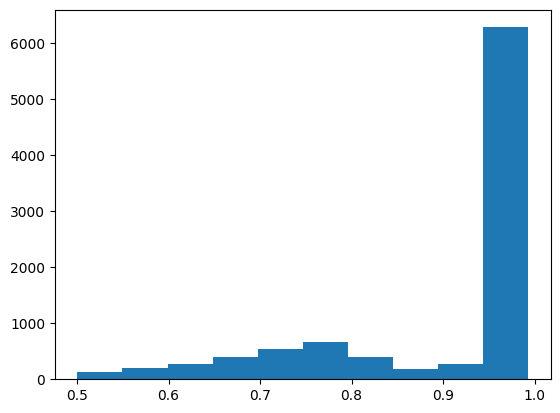

In [47]:
plt.hist(all_prob)

In [24]:
f1 = f1_score(all_label, all_label_pred)
#precision = precision_score(all_label, all_label_pred)
#roc_auc = roc_auc_score(all_label, all_probabilities)
recall = recall_score(all_label, all_label_pred)
print(f"F1 Score: {f1}")
#print(f"Precision (PPV): {precision}")
#print(f"ROC-AUC: {roc_auc}")
print(f"Recall: {recall}")


F1 Score: 0.9328932893289329
Recall: 0.8742268041237113


In [51]:
new_mirna_ensg2enst_prob = {}
for key, values in mirna_ensg2enst_prob.items():
    if len(values)>=7:# and key in aa:
        new_mirna_ensg2enst_prob[key] = values
count_label = 0        
new_mirna_ensg2enst_vec = {}
#new_mirna_ensg = []

for key, values in mirna_ensg2enst_vec.items():
    if len(values)>=7:# and key in aa:
        new_mirna_ensg2enst_vec[key] = values    

In [52]:
with open('reuslt/attention_vis_neg.json', 'w') as f:
    json.dump(new_mirna_ensg2enst_vec, f, indent=4)

with open('reuslt/prob_vis_neg.json', 'w') as f:
    json.dump(new_mirna_ensg2enst_prob, f, indent=4)

In [25]:
df1 = pd.DataFrame(list(new_mirna_ensg2enst_prob.items()), columns=['mirna@ensg', 'enst@prob'])
df2 = pd.DataFrame(list(new_mirna_ensg2enst_vec.items()), columns=['mirna@ensg', 'enst@attention'])

# Save to CSV
df1.to_csv('reuslt/prob_vis.csv', index=False)
df2.to_csv('reuslt/prob_vis.csv', index=False)

In [18]:
new_mirna_ensg2enst_vec.keys()

dict_keys(['ebv-miR-BART7-3p@ENSG00000177733', 'ebv-miR-BART2-3p@ENSG00000111335', 'ebv-miR-BART1-5p@ENSG00000156875', 'ebv-miR-BART3-5p@ENSG00000156671', 'ebv-miR-BART3-3p@ENSG00000141867', 'ebv-miR-BHRF1-2-5p@ENSG00000168769'])

In [40]:
del new_mirna_ensg2enst_vec['hsa-miR-130a-3p@ENSG00000127022']

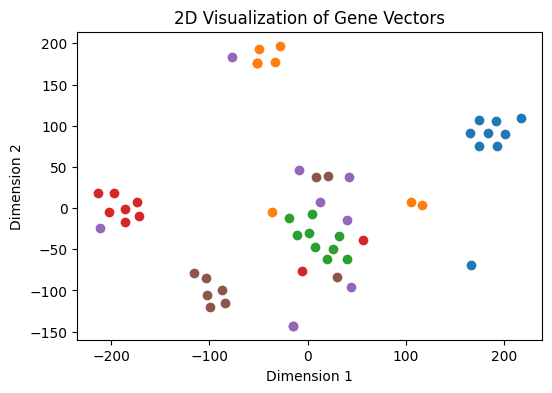

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
all_vectors = []
all_labels = []

for gene, vectors in new_mirna_ensg2enst_vec.items():
    for vec in vectors:
        all_vectors.append(vec[1])
        all_labels.append(gene)

all_vectors = np.vstack(all_vectors)  # shape (n_samples, 256)

# Step 2: Dimension reduction
# You can choose PCA or t-SNE
#pca = PCA(n_components=2)
# reduced = pca.fit_transform(all_vectors)

tsne = TSNE(n_components=2, random_state=42,perplexity=6,metric ='cosine')
reduced = tsne.fit_transform(all_vectors)

# Step 3: Plot
plt.figure(figsize=(6, 4))

# Assign a unique color to each gene
unique_genes = list(set(all_labels))
gene_to_color = {gene: idx for idx, gene in enumerate(unique_genes)}

for gene in unique_genes:
    idxs = [i for i, label in enumerate(all_labels) if label == gene]
    plt.scatter(reduced[idxs, 0], reduced[idxs, 1], label=gene)

#plt.legend()
plt.title('2D Visualization of Gene Vectors')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

In [9]:
aa = ['hsa-miR-29b-3p@ENSG00000198561','hsa-miR-7-5p@ENSG00000164733','hsa-miR-10a-5p@ENSG00000103275',
'hsa-miR-17-5p@ENSG00000168610','hsa-miR-26b-5p@ENSG00000119950','hsa-miR-27b-3p@ENSG00000116044']

In [55]:
aa

['hsa-miR-29b-3p@ENSG00000198561',
 'hsa-miR-7-5p@ENSG00000164733',
 'hsa-miR-10a-5p@ENSG00000103275',
 'hsa-miR-17-5p@ENSG00000168610',
 'hsa-miR-26b-5p@ENSG00000119950',
 'hsa-miR-27b-3p@ENSG00000116044']

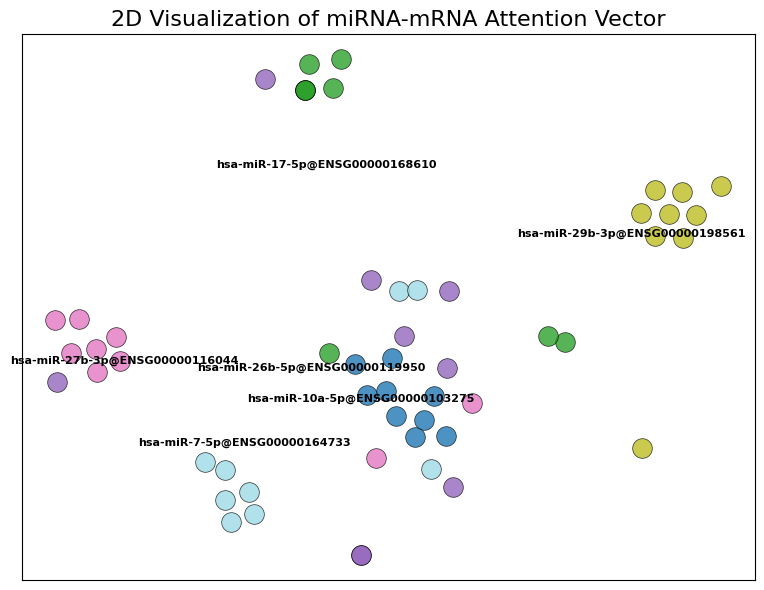

In [85]:
all_vectors = np.vstack(all_vectors)
all_labels = np.array(all_labels)

# Step 2: t-SNE for better separation
tsne = TSNE(n_components=2, random_state=42, perplexity=6,metric ='cosine')  # small perplexity because few points
reduced = tsne.fit_transform(all_vectors)

plt.figure(figsize=(8, 6))

unique_genes = np.unique(all_labels)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_genes)))  # nice color palette

for i, gene in enumerate(unique_genes):
    idxs = np.where(all_labels == gene)[0]
    plt.scatter(
        reduced[idxs, 0],
        reduced[idxs, 1],
        label=gene,
        color=colors[i],
        s=200,
        alpha=0.8,
        edgecolor='k',  # black edge for clearer points
        linewidth=0.5
    )
    # Optionally, add text near the center
    x_center = np.mean(reduced[idxs, 0])
    y_center = np.mean(reduced[idxs, 1])
    plt.text(x_center-100, y_center, gene, fontsize=8, weight='bold')

plt.grid(alpha=0.3)
plt.xticks([])
plt.yticks([])
plt.title('2D Visualization of miRNA-mRNA Attention Vector', fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns
genes = []
values_list = []
gene2prob = {}
for gene, scalars in new_mirna_ensg2enst_prob.items():
    genes.extend([gene] * len(scalars))
    values = []
    for ii in scalars:
        values.append(ii[1])
    values_list.append(values)
    gene2prob[gene] = values
values_list

[[0.34833,
  0.4452448,
  0.21206737,
  0.2943243,
  0.24510415,
  0.5372667,
  0.3618072,
  0.33798963,
  0.3863112],
 [0.68371046,
  0.68429756,
  0.67250884,
  0.68371046,
  0.68371046,
  0.68371046,
  0.68371046,
  0.68371046,
  0.68371046],
 [0.78463674,
  0.7040274,
  0.7313608,
  0.7229282,
  0.7040274,
  0.7040274,
  0.70224273,
  0.7244414,
  0.6998286],
 [0.4663513,
  0.26167992,
  0.31921345,
  0.5653598,
  0.4888261,
  0.5353702,
  0.47999567,
  0.48770046,
  0.54584146],
 [0.98204994,
  0.98191994,
  0.981618,
  0.98177516,
  0.98200583,
  0.9752926,
  0.98204994,
  0.9841204,
  0.98343074],
 [0.81233066,
  0.828121,
  0.79932445,
  0.8093426,
  0.85545665,
  0.78695536,
  0.8165993,
  0.8093426,
  0.8093426]]

In [95]:
new_mirna_ensg2enst_prob

{'hsa-miR-10a-5p@ENSG00000103275': [('ENST00000711335', 0.34833),
  ('ENST00000711344', 0.4452448),
  ('ENST00000677314', 0.21206737),
  ('ENST00000711340', 0.2943243),
  ('ENST00000713920', 0.24510415),
  ('ENST00000711339', 0.5372667),
  ('ENST00000713922', 0.3618072),
  ('ENST00000713916', 0.33798963),
  ('ENST00000711347', 0.3863112)],
 'hsa-miR-29b-3p@ENSG00000198561': [('ENST00000529986', 0.68371046),
  ('ENST00000683769', 0.68429756),
  ('ENST00000524630', 0.67250884),
  ('ENST00000526772', 0.68371046),
  ('ENST00000532649', 0.68371046),
  ('ENST00000528621', 0.68371046),
  ('ENST00000532463', 0.68371046),
  ('ENST00000361391', 0.68371046),
  ('ENST00000426142', 0.68371046)],
 'hsa-miR-17-5p@ENSG00000168610': [('ENST00000678535', 0.78463674),
  ('ENST00000678913', 0.7040274),
  ('ENST00000677030', 0.7313608),
  ('ENST00000264657', 0.7229282),
  ('ENST00000678043', 0.7040274),
  ('ENST00000677723', 0.7040274),
  ('ENST00000678044', 0.70224273),
  ('ENST00000679185', 0.7244414),
 

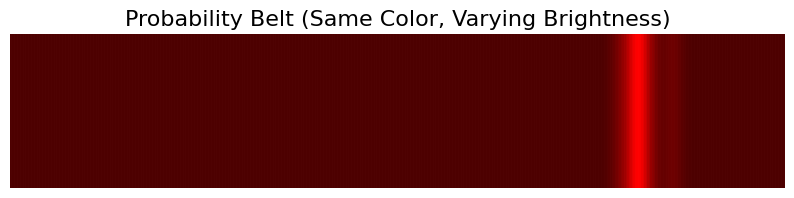

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib.colors as mcolors

# Example probability list
probs = values_list[5]  # random example

# Step 1: Estimate density using KDE
kde = gaussian_kde(probs, bw_method=0.5)

# Step 2: Prepare the belt
x = np.linspace(0, 1, 500)
density = kde(x)

# Step 3: Normalize density to [0,1]
density_normalized = (density - density.min()) / (density.max() - density.min())

# Step 4: Choose a base color
base_color = np.array(mcolors.to_rgb('red'))  # choose any base color you want

# Step 5: Plot
plt.figure(figsize=(10, 2))
for xi, di in zip(x, density_normalized):
    # Make color lighter where density is lower, darker where higher
    color = base_color * (0.3 + 0.7 * di)  # 0.3=minimum darkness, 1.0=maximum darkness
    color = np.clip(color, 0, 1)  # make sure RGB stays valid
    plt.plot([xi, xi], [0, 1], color=color, linewidth=2)

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')
plt.title('Probability Belt (Same Color, Varying Brightness)', fontsize=16)
plt.show()


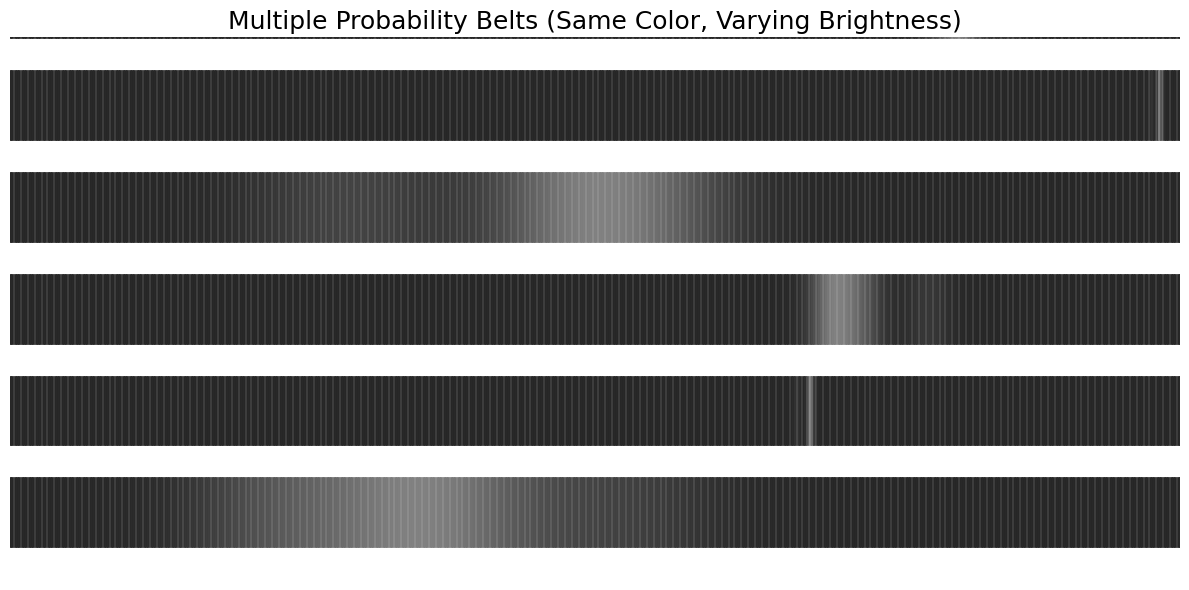

In [120]:
base_color = np.array(mcolors.to_rgb('gray'))  # same base color

# Set up plot
plt.figure(figsize=(12, 6))

for idx, probs in enumerate(values_list):
    # Step 1: Estimate density
    kde = gaussian_kde(probs, bw_method=0.5)
    x = np.linspace(0, 1, 500)
    density = kde(x)

    # Step 2: Normalize density
    density_normalized = (density - density.min()) / (density.max() - density.min())

    # Step 3: Plot belt at different y-level
    y_bottom = idx * 1.5  # spacing between belts
    y_top = y_bottom + 1

    for xi, di in zip(x, density_normalized):
        color = base_color * (0.3 + 0.7 * di)
        color = np.clip(color, 0, 1)
        plt.plot([xi, xi], [y_bottom, y_top], color=color, linewidth=2)
        plt.xlabel(aa[0])

# Make plot nice
plt.xlim(0, 1)
plt.ylim(-0.5, 5 * 1.5)
plt.axis('off')
plt.title('Multiple Probability Belts (Same Color, Varying Brightness)', fontsize=18)
plt.tight_layout()
plt.show()

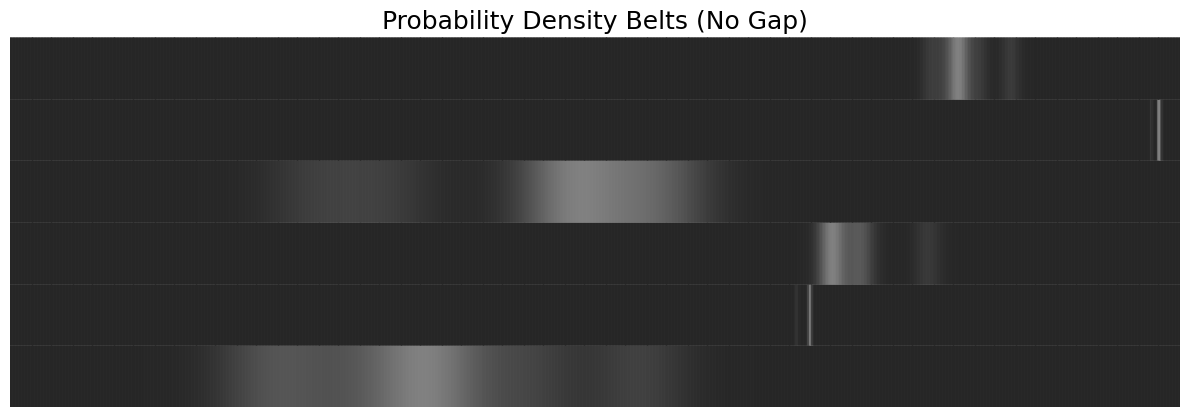

In [119]:
base_color = np.array(mcolors.to_rgb('gray'))

# Set up plot
plt.figure(figsize=(12, 4))

n_belts = len(values_list)
belt_height = 1 / n_belts  # Each belt takes 1/5th of total height

for idx, probs in enumerate(values_list):
    # Step 1: Estimate density
    kde = gaussian_kde(probs, bw_method=0.3)
    x = np.linspace(0, 1, 800)  # more points = smoother
    density = kde(x)

    # Step 2: Normalize density
    density_normalized = (density - density.min()) / (density.max() - density.min())

    # Step 3: Plot belt at proper y-range
    y_start = idx * belt_height
    y_end = (idx + 1) * belt_height

    for xi, di in zip(x, density_normalized):
        color = base_color * (0.3 + 0.7 * di)
        color = np.clip(color, 0, 1)
        plt.plot([xi, xi], [y_start, y_end], color=color, linewidth=2, solid_capstyle='butt')

# Clean the plot
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.axis('off')
plt.tight_layout()
plt.title('Probability Density Belts (No Gap)', fontsize=18)
plt.show()

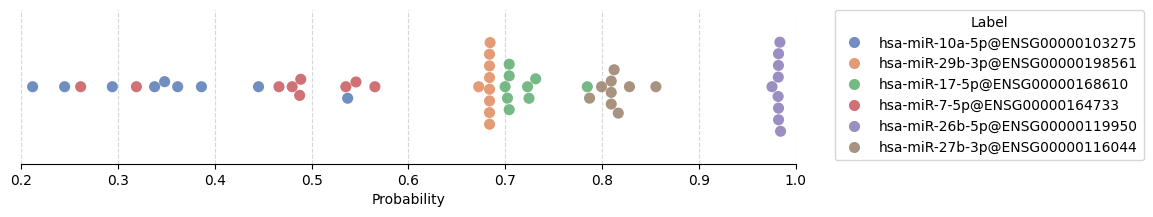

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example data
data = gene2prob
# Prepare DataFrame
df = pd.DataFrame([(label, val) for label, vals in data.items() for val in vals], columns=["Label", "Value"])

# Create the swarm plot
plt.figure(figsize=(10, 2))
sns.swarmplot(data=df, x="Value", y=[""]*len(df), hue="Label", size=8,alpha=0.8,palette="deep")

# Decorations
plt.xlabel('Probability')
plt.yticks([])  # No y-ticks (because you want them on one line)
#plt.title('Swarm plot: 1D values with label color')
plt.xlim(0.2, 1)  # Probabilities between 0 and 1
#plt.legend(title='Label')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax = plt.gca()
# Make all spines visible
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(False)
#plt.tight_layout()
#plt.show()
